# Battery State-of-Health Prediction — Single-Cycle Raw Data

## Project context
Each **flight / test run** produces one discharge cycle of voltage, current, and temperature measurements under a **dynamic load profile**.  
Data is **not** collected until end-of-life — the model must predict capacity (SoH proxy) from a single cycle's raw curve.

## Key design decisions vs summarized-feature approach
| | Summarized features | This notebook |
|---|---|---|
| Input per sample | 7 scalars (duration, v_drop, …) | Full V/I/T time-series (1 cycle) |
| History needed | Window of N past cycles | Just the current cycle |
| Works with 1 cycle? | No (needs window) | **Yes** |
| Captures intra-cycle dynamics | No | **Yes** |
| Memory | Low | Higher (manageable) |

## Pipeline overview
```
Raw .mat file
  └─ discharge cycles only
       └─ resample each curve to fixed length (500 pts)
            └─ stack V / I / T  → (500, 3) tensor per cycle
                 └─ models: CNN-LSTM  |  XGBoost (flattened)  |  Linear (flattened)
                      └─ predict: capacity (Ahr)  ← SoH proxy
```

In [1]:
# Install / verify dependencies
import subprocess, sys
for pkg in ['mlflow', 'xgboost']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Core imports ────────────────────────────────────────────────
import os, sys, platform, struct, warnings
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model  import LinearRegression
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except ImportError:
    xgb = None
    print('XGBoost not found.')

try:
    import tensorflow as tf 
    from tensorflow.keras.layers import (
        Input, LSTM, Dense,
        Dropout, Bidirectional
    )
    from tensorflow.keras.models import Model
except ImportError:
    tf = None
    print('TensorFlow not found.')

try:
    import mlflow, mlflow.keras, mlflow.sklearn
except ImportError:
    mlflow = None
    print('MLflow not found.')

# ── Environment check ────────────────────────────────────────────
bit = struct.calcsize('P') * 8
print(f'Python  : {sys.version}')
print(f'Arch    : {platform.architecture()[0]}  ({bit}-bit)')
if tf:    print(f'TF      : {tf.__version__}')
if xgb:   print(f'XGBoost : {xgb.__version__}')
if mlflow: print(f'MLflow  : {mlflow.__version__}')
print('\nAll ready.' if all([tf, xgb, mlflow]) else 'Some libraries missing — check above.')

Python  : 3.13.3 (main, Apr  8 2025, 13:54:08) [Clang 16.0.0 (clang-1600.0.26.6)]
Arch    : 64bit  (64-bit)
TF      : 2.21.0
XGBoost : 3.2.0
MLflow  : 3.12.0

All ready.


---
## 1 · Load raw discharge curves

In [3]:
# ── CONFIG ───────────────────────────────────────────────────────
# Point this at the folder containing B0005.mat … B0018.mat
DATA_PATH   = os.environ.get('NASA_DATA_PATH', '/Users/salmon/work/final_project/poc/1. BatteryAgingARC-FY08Q4')
BATTERY_IDS = [5, 6, 7, 18]

# Resampling length: every discharge curve is interpolated to this
# many equally-spaced points.  500 captures the main curve shape
N_TIMESTEPS = 1000

# Channels extracted per timestep
CHANNELS = ['Voltage_measured', 'Current_measured', 'Temperature_measured']
N_CH     = len(CHANNELS)   # 3


def resample_1d(arr, n):
    """Linearly interpolate a 1-D array to exactly n points."""
    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, arr).astype(np.float32)


def load_single_cycle_dataset(battery_ids, n_timesteps=N_TIMESTEPS):
    """
    For each battery, extract every discharge cycle and return:
      X  : (n_cycles, n_timesteps, 3)   — V / I / T resampled curves
      y  : (n_cycles,)                  — capacity (Ahr)
      meta : DataFrame                  — battery_id, cycle_idx per row

    Each row in X represents ONE full discharge event (one flight / test run).
    No windowing over multiple past cycles is needed.
    """
    X_list, y_list, meta_rows = [], [], []

    for b_id in battery_ids:
        key      = f'B00{b_id:02d}'
        fpath    = os.path.join(DATA_PATH, f'{key}.mat')
        mat      = scipy.io.loadmat(fpath)
        data     = mat[key][0, 0]
        cycles   = data['cycle'][0]

        for i, cyc in enumerate(cycles):
            if cyc['type'][0] != 'discharge':
                continue

            cd = cyc['data'][0, 0]

            # Capacity label  — skip cycles without it
            try:
                cap = float(cd['Capacity'][0][0])
            except (KeyError, IndexError, TypeError):
                continue

            # Extract and resample each channel
            channels = []
            ok = True
            for ch in CHANNELS:
                try:
                    raw = cd[ch][0].astype(np.float32)
                    if len(raw) < 10:          # degenerate cycle
                        ok = False; break
                    channels.append(resample_1d(raw, n_timesteps))
                except (KeyError, IndexError):
                    ok = False; break
            if not ok:
                continue

            # Stack → (n_timesteps, 3)
            X_list.append(np.stack(channels, axis=-1))
            y_list.append(cap)
            meta_rows.append({'battery_id': key, 'cycle_idx': i + 1})

    X    = np.array(X_list, dtype=np.float32)   # (N, 1000, 3)
    y    = np.array(y_list,  dtype=np.float32)   # (N,)
    meta = pd.DataFrame(meta_rows)
    return X, y, meta


print('Loading …')
X_all, y_all, meta = load_single_cycle_dataset(BATTERY_IDS)

print(f'\nX_all shape  : {X_all.shape}  → (n_cycles, timesteps, channels)')
print(f'y_all shape  : {y_all.shape}')
print(f'Capacity min : {y_all.min():.4f} Ahr')
print(f'Capacity max : {y_all.max():.4f} Ahr')
print()
print(meta.groupby('battery_id').size().rename('n_cycles').to_frame())

Loading …

X_all shape  : (636, 1000, 3)  → (n_cycles, timesteps, channels)
y_all shape  : (636,)
Capacity min : 1.1538 Ahr
Capacity max : 2.0353 Ahr

            n_cycles
battery_id          
B0005            168
B0006            168
B0007            168
B0018            132


---
## 2 · Exploratory data analysis

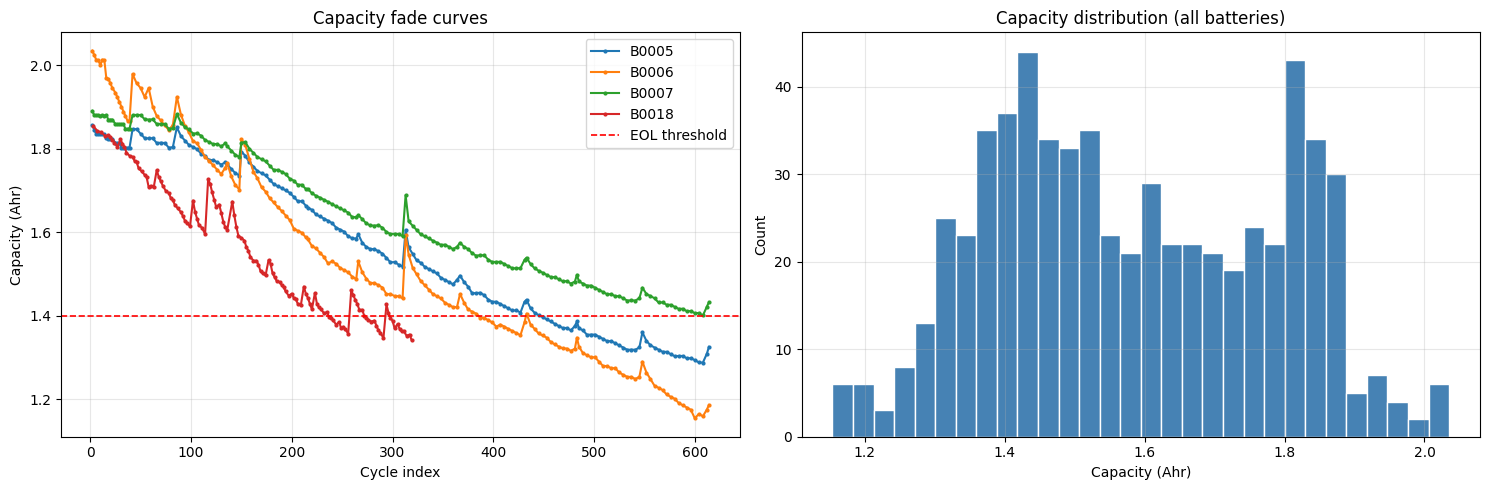

In [4]:
# ── EDA 1: Capacity fade per battery ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — capacity vs cycle index
ax = axes[0]
for bid, grp in meta.groupby('battery_id'):
    idx = grp.index
    ax.plot(grp['cycle_idx'], y_all[idx], label=bid, marker='o', markersize=2)
ax.axhline(1.4, color='red', linestyle='--', linewidth=1.2, label='EOL threshold')
ax.set_title('Capacity fade curves')
ax.set_xlabel('Cycle index'); ax.set_ylabel('Capacity (Ahr)')
ax.legend(); ax.grid(True, alpha=0.3)

# Right — capacity distribution
ax = axes[1]
ax.hist(y_all, bins=30, color='steelblue', edgecolor='white')
ax.set_title('Capacity distribution (all batteries)')
ax.set_xlabel('Capacity (Ahr)'); ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

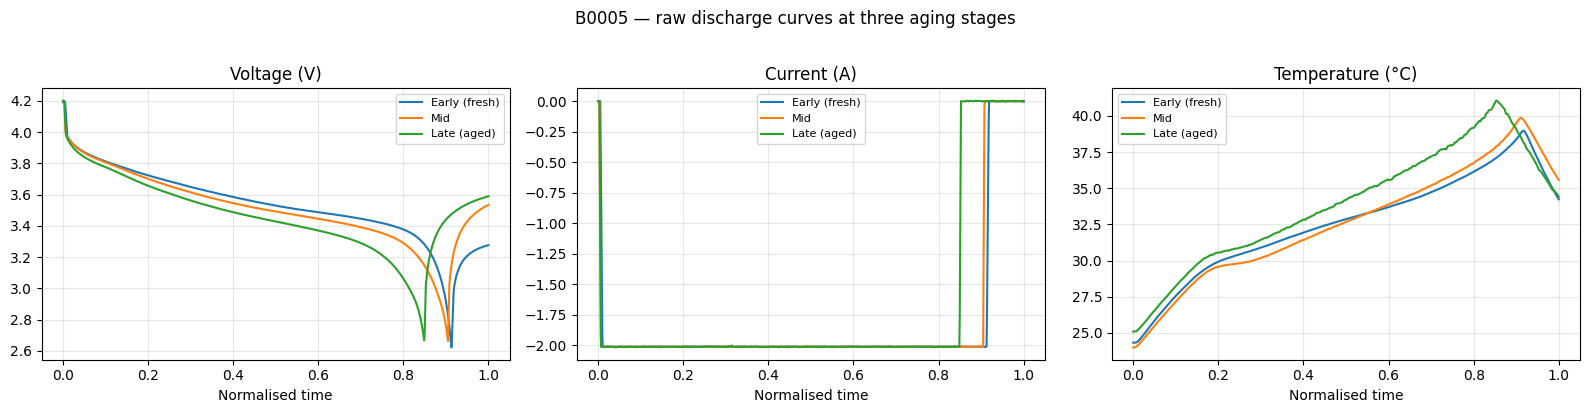

In [5]:
# ── EDA 2: Sample raw curves at different aging stages ───────────
# Pick B0005 cycles: early, mid, late
b5_mask  = (meta['battery_id'] == 'B0005').values
b5_idx   = np.where(b5_mask)[0]
n_b5     = len(b5_idx)
samples  = [b5_idx[0], b5_idx[n_b5 // 2], b5_idx[-1]]
labels   = ['Early (fresh)', 'Mid', 'Late (aged)']
ch_names = ['Voltage (V)', 'Current (A)', 'Temperature (°C)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
t = np.linspace(0, 1, N_TIMESTEPS)

for ch, ax in enumerate(axes):
    for s_idx, lbl in zip(samples, labels):
        ax.plot(t, X_all[s_idx, :, ch], label=lbl)
    ax.set_title(ch_names[ch])
    ax.set_xlabel('Normalised time')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('B0005 — raw discharge curves at three aging stages', y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · Train / test split & scaling

**Strategy:**  
- Train on **B0006, B0007, B0018**  
- Test on  **B0005**  (held-out battery — simulates deployment on an unseen unit)

Because we now use **one cycle = one sample**, no sliding window is needed.  
The scaler is fit per channel on training data only to prevent leakage.

In [6]:
TRAIN_IDS = ['B0006', 'B0007']
TEST_ID   = 'B0005'

train_mask = meta['battery_id'].isin(TRAIN_IDS).values
test_mask  = (meta['battery_id'] == TEST_ID).values

X_train_raw  = X_all[train_mask]   # (n_train, 1000, 3)
X_test_raw   = X_all[test_mask]
y_train      = y_all[train_mask]
y_test       = y_all[test_mask]

print(f'Train samples : {X_train_raw.shape[0]}  from {TRAIN_IDS}')
print(f'Test  samples : {X_test_raw.shape[0]}  from {TEST_ID}')

# ── Per-channel MinMax scaling ────────────────────────────────────
# Fit on training data; transform both train and test.
channel_scalers = []
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

for ch in range(N_CH):
    sc = MinMaxScaler()
    flat_tr  = X_train_raw[:, :, ch].reshape(-1, 1)
    flat_te  = X_test_raw[:, :, ch].reshape(-1, 1)
    X_train[:, :, ch] = sc.fit_transform(flat_tr).reshape(-1, N_TIMESTEPS)
    X_test[:, :, ch]  = sc.transform(flat_te).reshape(-1, N_TIMESTEPS)
    channel_scalers.append(sc)
    print(f'  Channel {CHANNELS[ch]:25s}  '
          f'train range [{flat_tr.min():.3f}, {flat_tr.max():.3f}]')

# ── Capacity scaler ───────────────────────────────────────────────
scaler_y       = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

# Flat versions for tree-based / linear models
X_train_flat = X_train.reshape(len(X_train), -1)   # (n_train, 1500)
X_test_flat  = X_test.reshape(len(X_test),  -1)    # (n_test,  1500)

print(f'\nX_train (scaled) : {X_train.shape}')
print(f'X_test  (scaled) : {X_test.shape}')
print(f'X_train_flat     : {X_train_flat.shape}  (for XGBoost / LR)')

Train samples : 336  from ['B0006', 'B0007']
Test  samples : 168  from B0005
  Channel Voltage_measured           train range [1.742, 4.233]
  Channel Current_measured           train range [-2.026, 0.008]
  Channel Temperature_measured       train range [22.971, 42.328]

X_train (scaled) : (336, 1000, 3)
X_test  (scaled) : (168, 1000, 3)
X_train_flat     : (336, 3000)  (for XGBoost / LR)


---
## 4 · MLflow — start run

In [7]:
if mlflow:
    mlflow.end_run()
    mlflow.set_experiment("UAV_Battery_Health_Ensemble")
    mlflow.start_run(run_name=f"Single_Cycle_BiLSTM_{TEST_ID}")

    # ── Dataset & split ──────────────────────────────────────────
    mlflow.log_params({
        "dataset"          : "NASA_B0005_B0006_B0007_B0018",
        "approach"         : "single_cycle_raw_curve",
        "test_battery"     : TEST_ID,
        "train_batteries"  : str(TRAIN_IDS),
        "n_timesteps"      : N_TIMESTEPS,
        "channels"         : str(CHANNELS),
        "n_train"          : X_train.shape[0],
        "n_test"           : X_test.shape[0],
    })

    # ── XGBoost config ───────────────────────────────────────────
    mlflow.log_params({
        "xgb_n_estimators"     : 300,
        "xgb_max_depth"        : 18,
        "xgb_learning_rate"    : 0.05,
        "xgb_subsample"        : 0.8,
        "xgb_colsample_bytree" : 0.3,
    })

    # ── LSTM config ──────────────────────────────────────────────
    mlflow.log_params({
        "lstm_architecture"        : "Stacked_BiLSTM",
        "lstm_layers"              : 3,
        "lstm_units_config"        : "128-64-32",
        "lstm_dropout_rates"       : "0.3-0.3-0.2",
        "lstm_dense_units"         : 32,
        "lstm_learning_rate"       : 3e-4,
        "lstm_batch_size"          : 32,
        "lstm_epochs_max"          : 100,
        "lstm_early_stop_patience" : 12,
        "lstm_reduce_lr_factor"    : 0.5,
        "lstm_reduce_lr_patience"  : 5,
        "lstm_reduce_lr_min"       : 1e-6,
        "lstm_optimizer"           : "Adam",
    })

    # ── Tags ─────────────────────────────────────────────────────
    mlflow.set_tags({
        "model_type"  : "Hybrid_Ensemble",
        "data_source" : "NASA_B0005_B0006_B0007_B0018",
        "framework"   : "TensorFlow_Keras_XGBoost",
    })

    print("MLflow run started.")

MLflow run started.


---
## 5 · Baseline — Linear Regression on flattened curve

In [8]:
lr = LinearRegression()
lr.fit(X_train_flat, y_train_scaled)

lr_preds = scaler_y.inverse_transform(
    lr.predict(X_test_flat).reshape(-1, 1)
).flatten()

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_r2   = r2_score(y_test, lr_preds)

print(f'Linear Regression  RMSE={lr_rmse:.4f}  MAE={lr_mae:.4f}  R²={lr_r2:.4f}')

if mlflow:
    mlflow.log_metric('LR_RMSE', lr_rmse)
    mlflow.log_metric('LR_R2',   lr_r2)
    mlflow.sklearn.log_model(lr, 'baseline_lr')

2026/05/09 16:46:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:46:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression  RMSE=0.0864  MAE=0.0832  R²=0.7929


---
## 6 · XGBoost on flattened curve

In [9]:
if xgb:
    xgb_model = XGBRegressor(
        n_estimators  = 300,
        max_depth     = 18,
        learning_rate = 0.05,
        subsample     = 0.8,
        colsample_bytree = 0.3,   # important: 1500 features → subsample columns
        random_state  = 42,
        n_jobs        = -1,
    )
    xgb_model.fit(
        X_train_flat, y_train_scaled,
        eval_set=[(X_test_flat, scaler_y.transform(y_test.reshape(-1,1)).flatten())],
        verbose=False
    )

    xgb_preds = scaler_y.inverse_transform(
        xgb_model.predict(X_test_flat).reshape(-1, 1)
    ).flatten()

    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
    xgb_mae  = mean_absolute_error(y_test, xgb_preds)
    xgb_r2   = r2_score(y_test, xgb_preds)
    print(f'XGBoost            RMSE={xgb_rmse:.4f}  MAE={xgb_mae:.4f}  R²={xgb_r2:.4f}')

    if mlflow:
        mlflow.log_metric('XGB_RMSE', xgb_rmse)
        mlflow.log_metric('XGB_R2',   xgb_r2)
        mlflow.sklearn.log_model(xgb_model, 'xgboost_flat')
else:
    print('XGBoost not available — skipping.')
    xgb_preds = None

2026/05/09 16:46:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:46:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost            RMSE=0.0734  MAE=0.0576  R²=0.8507


---
## 7 · bi direction-LSTM — learns from the raw curve directly


In [10]:
if tf:
    # Use a descriptive input name
    inp = Input(shape=(N_TIMESTEPS, N_CH), name='discharge_curve_input')

    # ── Stacked Bidirectional LSTM Architecture ─────────────────────────
    # We rename 'x' to 'bilstm_out' or similar to be explicit
    x = Bidirectional(LSTM(128, return_sequences=True))(inp)
    x = Dropout(0.3)(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)
    
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.2)(x)

    # ── Regression head ───────────────────────────────────────────
    x   = Dense(32, activation='relu')(x)
    out = Dense(1,  activation='linear', name='capacity_output')(x)

    # Change variable from cnn_lstm to bilstm_model
    bilstm_model = Model(inp, out, name='Stacked_BiLSTM_Model')
    
    bilstm_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='mse',
        metrics=['mae']
    )
    
    bilstm_model.summary()

    # ── MLflow Logging ────────────────────────────────────────────
    if mlflow:
        # End any existing runs to prevent "Active Run" errors
        mlflow.end_run() 
        mlflow.start_run(run_name='Stacked_BiLSTM_NASA_B5_Test')
        
        mlflow.log_param('architecture',   'Stacked Bidirectional LSTM')
        mlflow.log_param('model_params',   bilstm_model.count_params())
        mlflow.log_param('lstm_layers',    3)
        mlflow.log_param('units_config',   '256-128-64')
        mlflow.log_param('dropout_rates',  '0.3-0.3-0.2')
        mlflow.log_param('learning_rate',  3e-4)
        
        print("MLflow: Logged parameters for Stacked BiLSTM model.")
else:
    print('TensorFlow not available.')

Model: "Stacked_BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ discharge_curve_input           │ (None, 1000, 3)        │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1000, 256)      │       135,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1000, 128)      │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capacity_output (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342,849 (1.31 MB)

 Trainable params: 342,849 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

MLflow: Logged parameters for Stacked BiLSTM model.


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Setup Callbacks (MLOps Best Practice)
# EarlyStopping stops training if the model stops improving to save time/energy
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=12, 
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau lowers learning rate if the model gets "stuck"
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

print(f"Starting training... Target Test Battery: {TEST_ID}")

# 2. RUN THE TRAINING (This creates the 'history' object)
history = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,             # Maximum iterations
    batch_size=32,          # Number of cycles per gradient update
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Training complete! You can now run the plotting cells in Part 8.")

Starting training... Target Test Battery: B0005
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - loss: 2.0419 - mae: 1.3996 - val_loss: 0.9836 - val_mae: 0.9737 - learning_rate: 3.0000e-04
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.6452 - mae: 0.7173 - val_loss: 0.0364 - val_mae: 0.1684 - learning_rate: 3.0000e-04
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.1286 - mae: 0.2925 - val_loss: 0.1234 - val_mae: 0.2975 - learning_rate: 3.0000e-04
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 984ms/step - loss: 0.0963 - mae: 0.2592 - val_loss: 0.0357 - val_mae: 0.1684 - learning_rate: 3.0000e-04
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 987ms/step - loss: 0.0919 - mae: 0.2451 - val_loss: 0.0418 - val_mae: 0.1797 - learning_rate: 3.0000e-04
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 985ms/step - loss: 0.0893 - mae: 0.2424 - val_loss: 0.0363 - val_mae: 0.1712 - learning_rate: 3.0000e-04
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 991ms/step - loss: 0.0717 - ma

---
## 8 · Training history

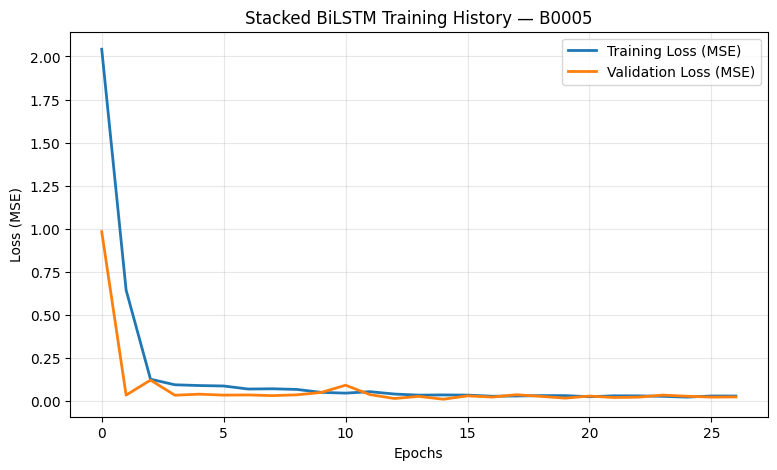

In [12]:
# --- PART 8: Training History ---
import matplotlib.pyplot as plt

# Check if training history exists (from the .fit() call)
if 'history' in locals() or 'history' in globals():
    plt.figure(figsize=(9, 5))
    plt.plot(history.history['loss'],     label='Training Loss (MSE)',   color='#1f77b4', lw=2)
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#ff7f0e', lw=2)
    plt.title(f'Stacked BiLSTM Training History — {TEST_ID}', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: 'history' not found. Did you run the 'history = bilstm_model.fit(...)' cell?")

---
## 9 · Evaluation & comparison

Generating BiLSTM predictions...
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 374ms/step


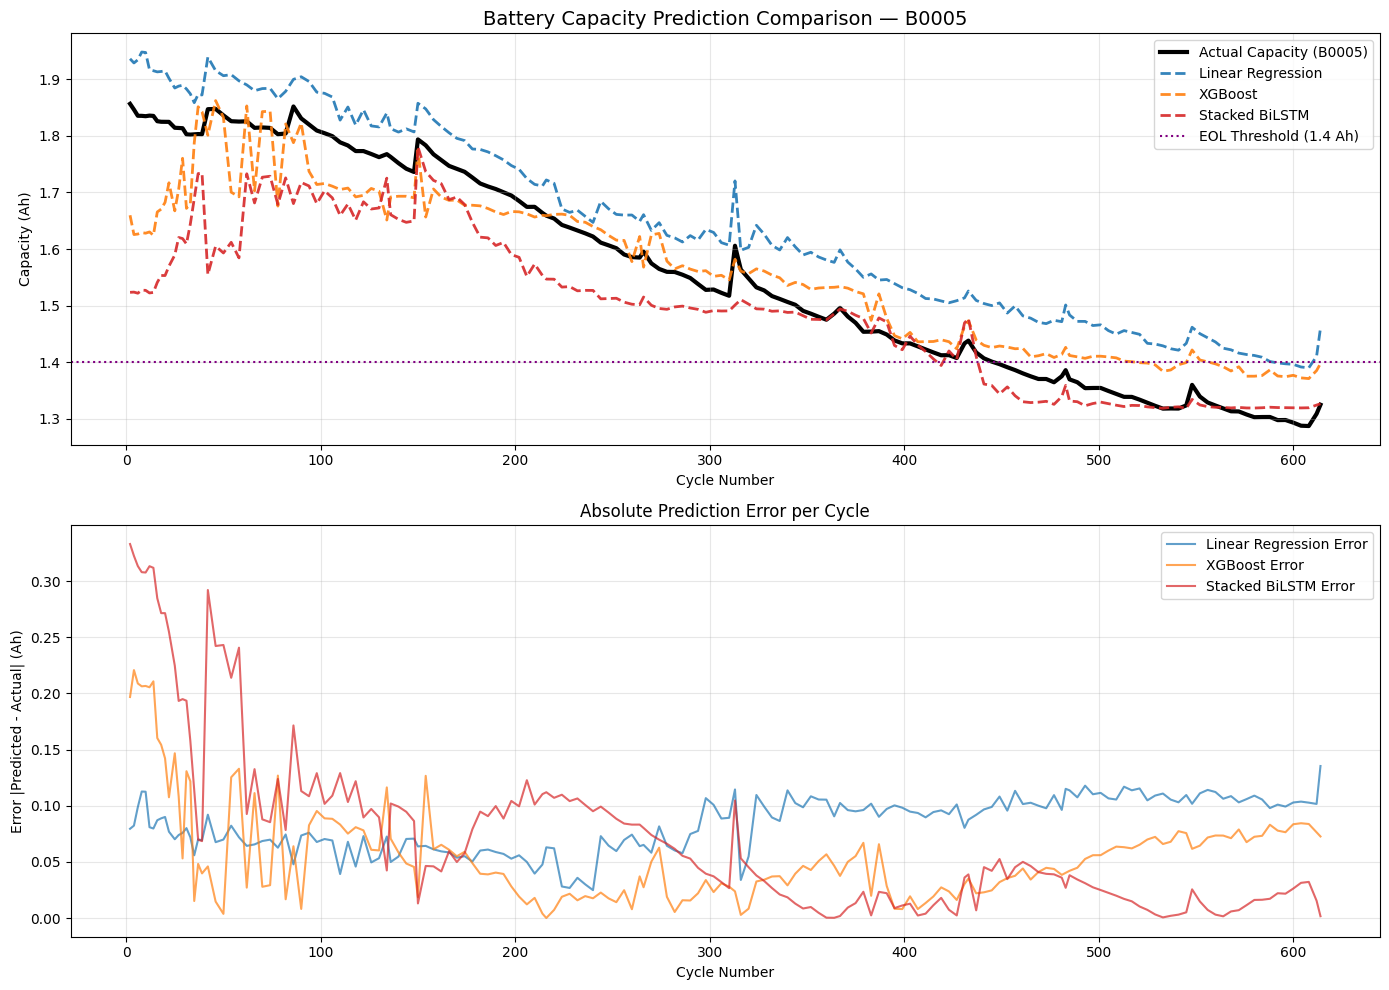

In [13]:
# 1. Generate the BiLSTM predictions if they don't exist yet
if 'bilstm_model' in locals():
    print("Generating BiLSTM predictions...")
    bilstm_preds = bilstm_model.predict(X_test).flatten()

# 2. Build the dictionary of all models for plotting
model_preds = {}
if 'lr_preds' in locals():    model_preds['Linear Regression'] = lr_preds
if 'xgb_preds' in locals():   model_preds['XGBoost'] = xgb_preds
if 'bilstm_preds' in locals(): model_preds['Stacked BiLSTM'] = bilstm_preds

# 3. Create the Visual Comparison Graph
cycle_nums = meta.loc[test_mask, 'cycle_idx'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top Plot: Capacity Trends ---
ax = axes[0]
ax.plot(cycle_nums, y_test, 'k-', lw=3, label=f'Actual Capacity ({TEST_ID})', zorder=1)

# List of distinct colors to ensure every model is visible
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c'] 

for (name, preds), color in zip(model_preds.items(), colors):
    ax.plot(cycle_nums, preds, '--', color=color, lw=2, alpha=0.9, label=name)

ax.axhline(1.4, color='purple', linestyle=':', lw=1.5, label='EOL Threshold (1.4 Ah)')
ax.set_title(f'Battery Capacity Prediction Comparison — {TEST_ID}', fontsize=14)
ax.set_xlabel('Cycle Number')
ax.set_ylabel('Capacity (Ah)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# --- Bottom Plot: Absolute Error ---
ax = axes[1]
for (name, preds), color in zip(model_preds.items(), colors):
    error = np.abs(y_test.flatten() - preds.flatten())
    ax.plot(cycle_nums, error, color=color, lw=1.5, alpha=0.7, label=f'{name} Error')

ax.set_title('Absolute Prediction Error per Cycle', fontsize=12)
ax.set_xlabel('Cycle Number')
ax.set_ylabel('Error |Predicted - Actual| (Ah)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── Summarize Performance Table ──────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Ensure all predictions are ready
# (Run this if you haven't generated BiLSTM preds yet)
if 'bilstm_model' in locals() and 'bilstm_preds' not in locals():
    bilstm_preds = bilstm_model.predict(X_test).flatten()

# 2. Build the model dictionary
# We use the names you requested for the table index
model_data = {}

if 'lr_preds' in locals():
    model_data['Linear_Regression'] = lr_preds
if 'xgb_preds' in locals():
    model_data['XGBoost'] = xgb_preds
if 'bilstm_preds' in locals():
    model_data['BiLSTM_Hybrid'] = bilstm_preds

# 3. Calculate metrics and build the list
performance_list = []

for name, preds in model_data.items():
    # Flatten arrays to ensure they match y_test shape
    y_true = y_test.flatten()
    y_pred = preds.flatten()
    
    performance_list.append({
        'Model': name,
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 6),
        'MAE': round(mean_absolute_error(y_true, y_pred), 6),
        'R2': round(r2_score(y_true, y_pred), 6)
    })

# 4. Create DataFrame and display
if performance_list:
    performance_df = pd.DataFrame(performance_list)
    # Display without the index to match your requested format
    print(performance_df.to_string(index=True))
else:
    print("No model predictions found. Please run the training cells first.")

               Model      RMSE       MAE        R2
0  Linear_Regression  0.086386  0.083238  0.792946
1            XGBoost  0.073354  0.057591  0.850706
2      BiLSTM_Hybrid  0.111997  0.077482  0.651972


In [15]:
# ── Detailed Cycle-by-Cycle Performance Log ──────────────────────
import pandas as pd

# 1. Ensure predictions are ready
if 'bilstm_preds' not in locals():
    bilstm_preds = bilstm_model.predict(X_test).flatten()

# 2. Get cycle indices from the metadata
test_cycles = meta.loc[test_mask, 'cycle_idx'].values
actual_cap = y_test.flatten()

# 3. Create a detailed dataframe
cycle_log = pd.DataFrame({
    'Cycle_ID': test_cycles,
    'Actual_Ah': actual_cap,
    'Predicted_Ah': bilstm_preds,
    'Abs_Error': np.abs(actual_cap - bilstm_preds),
    'Error_Percentage': (np.abs(actual_cap - bilstm_preds) / actual_cap) * 100
})

# 4. Show snippets of the battery life
print(f"--- Battery {TEST_ID} Life-Cycle Detailed Performance ---")
print("\n[FIRST 5 CYCLES - FRESH]")
print(cycle_log.head(5).to_string(index=False))

print("\n[MID-LIFE CYCLES]")
print(cycle_log.iloc[len(cycle_log)//2 : len(cycle_log)//2 + 5].to_string(index=False))

print("\n[LAST 5 CYCLES - AGED/EOL]")
print(cycle_log.tail(5).to_string(index=False))

# Calculate Average Error for this specific battery
avg_err = cycle_log['Abs_Error'].mean()
print(f"\nOverall Average Prediction Error for {TEST_ID}: {avg_err:.5f} Ah")

--- Battery B0005 Life-Cycle Detailed Performance ---

[FIRST 5 CYCLES - FRESH]
 Cycle_ID  Actual_Ah  Predicted_Ah  Abs_Error  Error_Percentage
        2   1.856487      1.523559   0.332928         17.933226
        4   1.846327      1.523931   0.322397         17.461504
        6   1.835349      1.522016   0.313333         17.072134
        8   1.835263      1.527380   0.307882         16.775934
       10   1.834646      1.527064   0.307582         16.765175

[MID-LIFE CYCLES]
 Cycle_ID  Actual_Ah  Predicted_Ah  Abs_Error  Error_Percentage
      294   1.538237      1.493461   0.044776          2.910871
      298   1.527914      1.488347   0.039567          2.589632
      302   1.528525      1.491296   0.037229          2.435620
      306   1.522647      1.490578   0.032069          2.106164
      310   1.517486      1.490800   0.026686          1.758587

[LAST 5 CYCLES - AGED/EOL]
 Cycle_ID  Actual_Ah  Predicted_Ah  Abs_Error  Error_Percentage
      600   1.293464      1.319775   0.02

---
## 10 · Close MLflow run

In [16]:
# ── Log metrics for all models ───────────────────────────────────
if mlflow:
    # Linear Regression
    mlflow.log_metrics({
        "LR_RMSE" : lr_rmse,
        "LR_MAE"  : lr_mae,
        "LR_R2"   : lr_r2,
    })
    mlflow.sklearn.log_model(lr, "baseline_lr")

    # XGBoost
    mlflow.log_metrics({
        "XGB_RMSE" : xgb_rmse,
        "XGB_MAE"  : xgb_mae,
        "XGB_R2"   : xgb_r2,
    })
    mlflow.sklearn.log_model(xgb_model, "xgboost_flat")

    # BiLSTM
    mlflow.log_metrics({
        "LSTM_RMSE" : round(np.sqrt(mean_squared_error(y_test, bilstm_preds)), 6),
        "LSTM_MAE"  : round(mean_absolute_error(y_test, bilstm_preds), 6),
        "LSTM_R2"   : round(r2_score(y_test, bilstm_preds), 6),
    })
    mlflow.keras.log_model(bilstm_model, "bilstm_model")

2026/05/09 16:52:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:52:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/09 16:52:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:52:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [17]:
if mlflow:
    mlflow.end_run()
    print('MLflow run closed.')
print('Done.')

MLflow run closed.
Done.


---
## Feature important


--- Channel-level Feature Importance ---
  Voltage_measured              : 0.000408
  Current_measured              : 0.000018
  Temperature_measured          : 0.000575


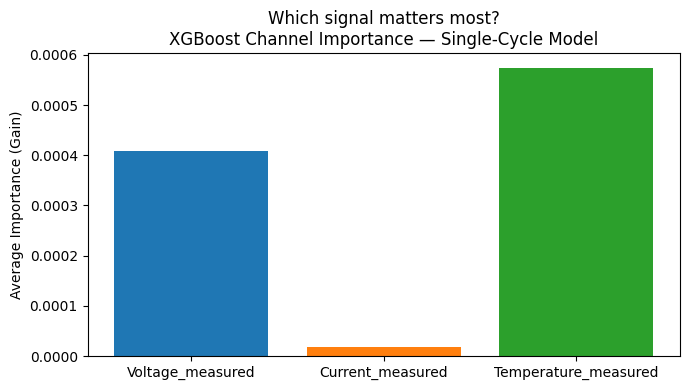

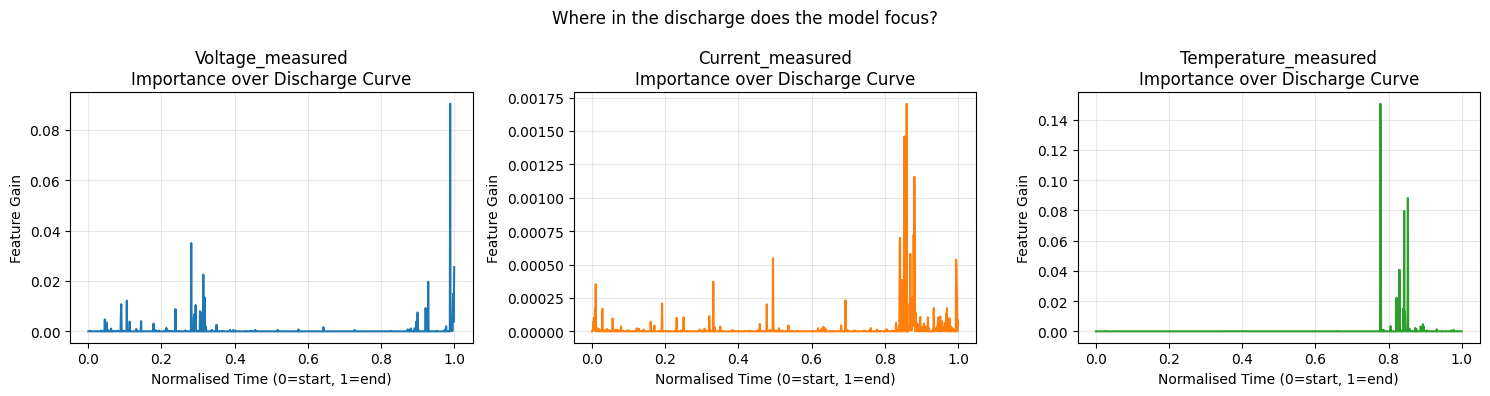


--- Domain Interpretation ---

  Voltage_measured (importance=0.000408)
    → Voltage curve shape directly reflects electrochemical state. End-of-discharge voltage drop is the key aging indicator.

  Current_measured (importance=0.000018)
    → Current profile reveals internal resistance changes. A degraded cell shows faster current decay under load.

  Temperature_measured (importance=0.000575)
    → Heat generated during discharge increases with internal resistance. Higher temperatures = more capacity loss per cycle.


In [18]:
# ── B5: Feature Importance — Single-Cycle XGBoost ────────────────
# The flat input is (N_TIMESTEPS * N_CH) = 3000 features.
# We aggregate importance by channel to get interpretable results.
import numpy as np
import matplotlib.pyplot as plt

raw_importance = xgb_model.feature_importances_   # shape: (3000,)

# Reshape to (N_TIMESTEPS, N_CH) and average over timesteps per channel
imp_by_channel_time = raw_importance.reshape(N_TIMESTEPS, N_CH)
channel_importance  = imp_by_channel_time.mean(axis=0)

print("--- Channel-level Feature Importance ---")
for ch_name, imp in zip(CHANNELS, channel_importance):
    print(f"  {ch_name:<30s}: {imp:.6f}")

# Bar chart per channel
plt.figure(figsize=(7, 4))
plt.bar(CHANNELS, channel_importance, color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.ylabel("Average Importance (Gain)")
plt.title("Which signal matters most?\nXGBoost Channel Importance — Single-Cycle Model")
plt.tight_layout()
plt.savefig("single_cycle_channel_importance.png", dpi=150)
plt.show()

# Importance over time (which part of the discharge curve matters?)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t = np.linspace(0, 1, N_TIMESTEPS)
for ch, (ax, ch_name) in enumerate(zip(axes, CHANNELS)):
    ax.plot(t, imp_by_channel_time[:, ch], color=['#1f77b4','#ff7f0e','#2ca02c'][ch])
    ax.set_title(f"{ch_name}\nImportance over Discharge Curve")
    ax.set_xlabel("Normalised Time (0=start, 1=end)")
    ax.set_ylabel("Feature Gain")
    ax.grid(True, alpha=0.3)
plt.suptitle("Where in the discharge does the model focus?", fontsize=12)
plt.tight_layout()
plt.savefig("single_cycle_temporal_importance.png", dpi=150)
plt.show()

print("\n--- Domain Interpretation ---")
ch_hints = {
    'Voltage_measured'     : "Voltage curve shape directly reflects electrochemical state. "
                             "End-of-discharge voltage drop is the key aging indicator.",
    'Current_measured'     : "Current profile reveals internal resistance changes. "
                             "A degraded cell shows faster current decay under load.",
    'Temperature_measured' : "Heat generated during discharge increases with internal resistance. "
                             "Higher temperatures = more capacity loss per cycle.",
}
for ch_name, imp in zip(CHANNELS, channel_importance):
    print(f"\n  {ch_name} (importance={imp:.6f})")
    print(f"    → {ch_hints.get(ch_name, '')}")

---
## Shap reasoning


In [19]:
# ── B6: SHAP for Single-Cycle XGBoost ───────────────────────────
import shap
import pandas as pd

# Create column names: e.g. "V_t000", "I_t000", "T_t000", ...
ch_short   = ['V', 'I', 'T']
col_names  = [f"{ch_short[ch]}_t{t:03d}" 
              for t in range(N_TIMESTEPS) for ch in range(N_CH)]

X_test_flat_df  = pd.DataFrame(X_test_flat,  columns=col_names)
X_train_flat_df = pd.DataFrame(X_train_flat, columns=col_names)

# SHAP — use a small background sample (KernelExplainer is slow on 3000 features)
background     = shap.sample(X_train_flat_df, 50)
explainer_xgb  = shap.TreeExplainer(xgb_model, background)
shap_values_xgb = explainer_xgb(X_test_flat_df)


  Case     : Early Cycle (Fresh Battery)
  Cycle #  : 2
  Predicted Capacity : 1.6597 Ahr
  Actual Capacity    : 1.8565 Ahr
  Absolute Error     : 0.1968 Ahr

  🔋 Plain-Language Explanation:
     The model estimates 1.660 Ahr capacity for this discharge cycle.
     • Voltage: slightly pushed prediction UP (contribution: +0.0231 Ahr)
     • Current: slightly pushed prediction UP (contribution: +0.0083 Ahr)
     • Temperature: strongly pushed prediction UP (contribution: +0.0585 Ahr)
     Battery Status: ✅ Healthy (83.0% of nominal 2.0 Ahr)


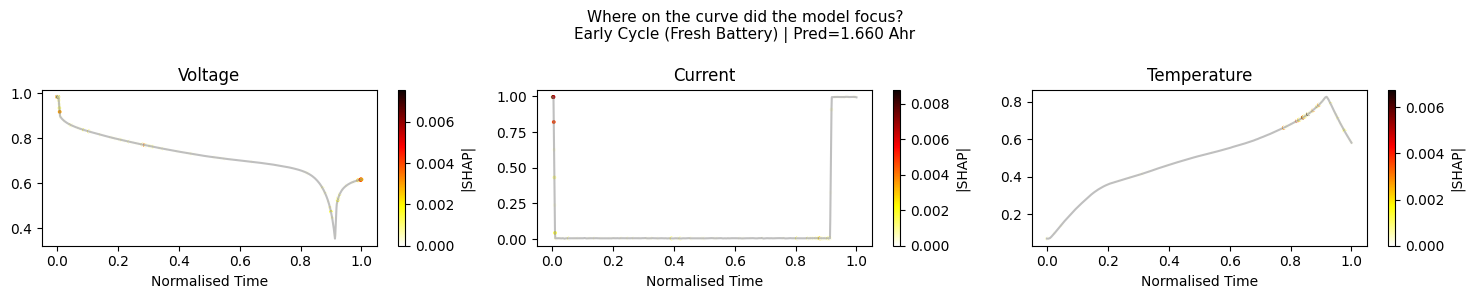


  Case     : Mid-Life (Moderate Degradation)
  Cycle #  : 294
  Predicted Capacity : 1.5604 Ahr
  Actual Capacity    : 1.5382 Ahr
  Absolute Error     : 0.0221 Ahr

  🔋 Plain-Language Explanation:
     The model estimates 1.560 Ahr capacity for this discharge cycle.
     • Voltage: slightly pushed prediction DOWN (contribution: -0.0307 Ahr)
     • Current: slightly pushed prediction UP (contribution: +0.0398 Ahr)
     • Temperature: slightly pushed prediction DOWN (contribution: -0.0319 Ahr)
     Battery Status: ⚠️ Degrading (78.0% of nominal 2.0 Ahr)


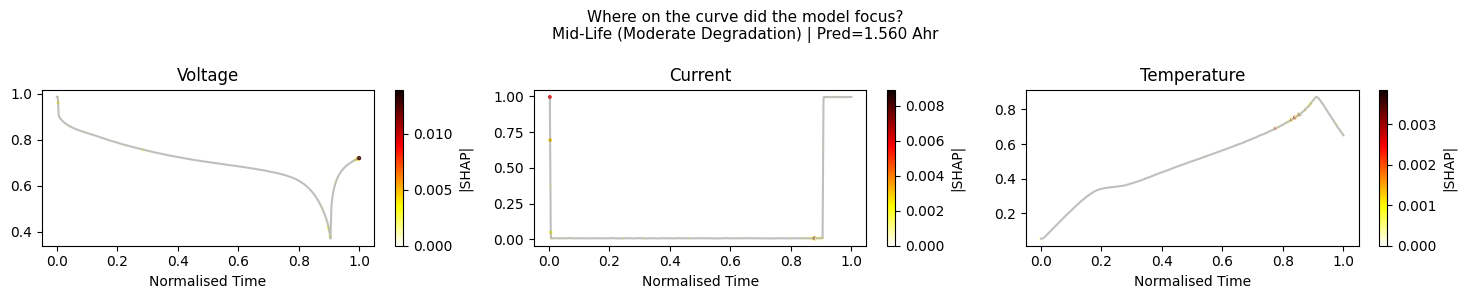


  Case     : Near End-of-Life
  Cycle #  : 614
  Predicted Capacity : 1.3978 Ahr
  Actual Capacity    : 1.3251 Ahr
  Absolute Error     : 0.0727 Ahr

  🔋 Plain-Language Explanation:
     The model estimates 1.398 Ahr capacity for this discharge cycle.
     • Voltage: strongly pushed prediction DOWN (contribution: -0.1010 Ahr)
     • Current: strongly pushed prediction DOWN (contribution: -0.0586 Ahr)
     • Temperature: slightly pushed prediction DOWN (contribution: -0.0476 Ahr)
     Battery Status: ❌ Near End-of-Life (69.9% of nominal 2.0 Ahr)


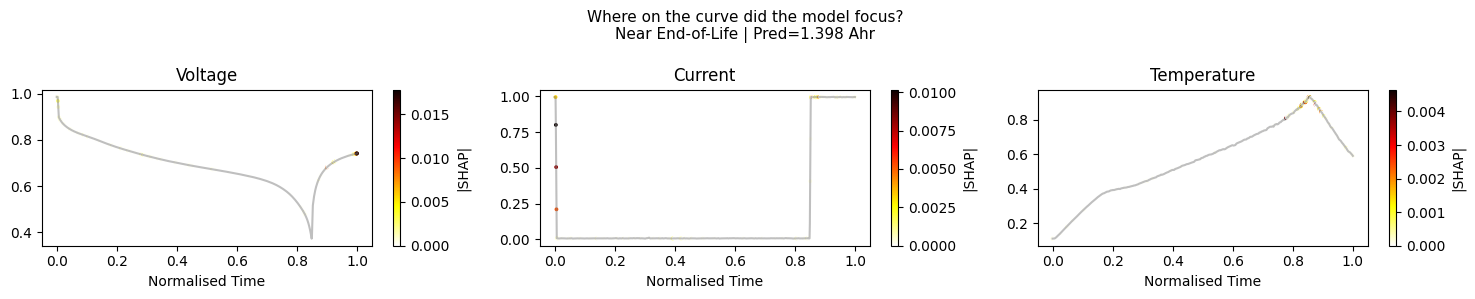

In [20]:
# ── B6: 3 Individual Test Cases — Single-Cycle ───────────────────
test_cycles_sc = meta.loc[test_mask, 'cycle_idx'].values

case_indices = [0, len(X_test_flat_df)//2, len(X_test_flat_df)-1]
case_labels  = [
    "Early Cycle (Fresh Battery)",
    "Mid-Life (Moderate Degradation)",
    "Near End-of-Life"
]

for idx, label in zip(case_indices, case_labels):
    sample_flat  = X_test_flat_df.iloc[[idx]]
    pred_scaled  = xgb_model.predict(sample_flat)[0]
    pred         = scaler_y.inverse_transform([[pred_scaled]])[0][0]
    actual       = y_test[idx]
    cycle_num    = test_cycles_sc[idx]

    print(f"\n{'='*65}")
    print(f"  Case     : {label}")
    print(f"  Cycle #  : {cycle_num}")
    print(f"  Predicted Capacity : {pred:.4f} Ahr")
    print(f"  Actual Capacity    : {actual:.4f} Ahr")
    print(f"  Absolute Error     : {abs(pred - actual):.4f} Ahr")

    # Aggregate SHAP by channel for plain-language output
    sv_flat = shap_values_xgb.values[idx]              # (3000,)
    sv_3d   = sv_flat.reshape(N_TIMESTEPS, N_CH)       # (1000, 3)
    ch_shap = sv_3d.sum(axis=0)                        # net SHAP per channel

    print(f"\n  🔋 Plain-Language Explanation:")
    print(f"     The model estimates {pred:.3f} Ahr capacity for this discharge cycle.")
    for ch, (ch_name, sv) in enumerate(zip(CHANNELS, ch_shap)):
        direction = "pushed prediction UP" if sv > 0 else "pushed prediction DOWN"
        magnitude = "strongly" if abs(sv) > 0.05 else "slightly"
        short = ch_name.replace("_measured","")
        print(f"     • {short}: {magnitude} {direction} (contribution: {sv:+.4f} Ahr)")

    health_pct = (pred / 2.0) * 100
    status = "✅ Healthy" if pred > 1.6 else ("⚠️ Degrading" if pred > 1.4 else "❌ Near End-of-Life")
    print(f"     Battery Status: {status} ({health_pct:.1f}% of nominal 2.0 Ahr)")

    # Visualise the raw curve for this cycle coloured by SHAP magnitude
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    t = np.linspace(0, 1, N_TIMESTEPS)
    for ch, ax in enumerate(axes):
        ax.plot(t, X_test[idx, :, ch], color='grey', alpha=0.5, label='Signal')
        sc = ax.scatter(t, X_test[idx, :, ch],
                        c=np.abs(sv_3d[:, ch]), cmap='hot_r', s=3)
        plt.colorbar(sc, ax=ax, label='|SHAP|')
        ax.set_title(CHANNELS[ch].replace("_measured",""))
        ax.set_xlabel("Normalised Time")
    plt.suptitle(f"Where on the curve did the model focus?\n{label} | Pred={pred:.3f} Ahr", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"single_cycle_shap_curve_{idx}.png", dpi=150)
    plt.show()

---
## Save models & best model for pipeline


In [87]:
import os, json, joblib

SINGLE_SAVE_DIR = './saved_models/single_cycle'
os.makedirs(SINGLE_SAVE_DIR, exist_ok=True)

bilstm_model.save(os.path.join(SINGLE_SAVE_DIR, 'lstm_model.keras'))  # rename if needed
joblib.dump(lr,          os.path.join(SINGLE_SAVE_DIR, 'lr_model.pkl'))
joblib.dump(xgb_model,         os.path.join(SINGLE_SAVE_DIR, 'xgb_model.pkl'))
joblib.dump(channel_scalers,   os.path.join(SINGLE_SAVE_DIR, 'channel_scalers.pkl'))
joblib.dump(scaler_y,          os.path.join(SINGLE_SAVE_DIR, 'scaler_y.pkl'))

config = {'n_timesteps': N_TIMESTEPS, 'channels': CHANNELS}
with open(os.path.join(SINGLE_SAVE_DIR, 'config.json'), 'w') as f:
    json.dump(config, f)
print('Single-cycle artifacts saved.')

Single-cycle artifacts saved.
